In [1]:
# Libraries for data manipulation
from pathlib import Path
import pandas as pd
import numpy as np

# Project paths
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data" / "raw"

# Load required datasets
customers = pd.read_csv(DATA_DIR / "customers.csv")
policies = pd.read_csv(DATA_DIR / "policies.csv")
claims = pd.read_csv(DATA_DIR / "claims.csv")
premiums = pd.read_csv(DATA_DIR / "premiums.csv")
renewals = pd.read_csv(DATA_DIR / "renewals.csv")

print("Data loaded successfully")

Data loaded successfully


In [2]:
# Renewal table will be our base because one row = one renewal event
renewal_df = renewals.copy()

print(renewal_df.shape)
renewal_df.head()

(20000, 12)


,RENEWAL_ID,POLICY_ID,CUSTOMER_ID,RENEWAL_DUE_DATE,OLD_PREMIUM,NEW_PREMIUM,PREMIUM_INCREASE_PCT,CLAIM_HISTORY_FLAG,LOYALTY_YEARS,RENEWAL_PROBABILITY,RENEWAL_STATUS,CONTACT_CHANNEL
0,REN00000001,POL000051250,CUST00059258,2025-06-17,11390,12441,9.23,Yes,7,0.8376,Renewed,WhatsApp
1,REN00000002,POL000017253,CUST00094235,2026-08-14,13513,13983,3.48,No,5,0.9200,Renewed,SMS
2,REN00000003,POL000108220,CUST00031120,2025-04-17,20696,20942,1.19,No,2,0.8960,Renewed,SMS
3,REN00000004,POL000068626,CUST00061811,2025-08-30,11112,11584,4.25,No,7,0.9360,Renewed,Call
4,REN00000005,POL000134055,CUST00024866,2026-02-13,13833,15043,8.75,Yes,4,0.8208,Renewed,SMS


In [3]:
# Check target classes before modeling
renewal_df["RENEWAL_STATUS"].value_counts()

RENEWAL_STATUS
Renewed      17334
Lapsed        1463
Pending        796
Cancelled      407
Name: count, dtype: int64

In [4]:
# Calculate percentage change between old and new premium
renewal_df["PREMIUM_INCREASE_PCT"] = (
    (renewal_df["NEW_PREMIUM"] - renewal_df["OLD_PREMIUM"])
    / renewal_df["OLD_PREMIUM"]
) * 100

In [5]:
# Inspect newly created feature
renewal_df[
    ["OLD_PREMIUM", "NEW_PREMIUM", "PREMIUM_INCREASE_PCT"]
].head()

,OLD_PREMIUM,NEW_PREMIUM,PREMIUM_INCREASE_PCT
0,11390,12441,9.227392
1,13513,13983,3.478132
2,20696,20942,1.188635
3,11112,11584,4.247660
4,13833,15043,8.747199


In [6]:
# Select only useful policy columns
policy_features = policies[
    [
        "POLICY_ID",
        "CUSTOMER_ID",
        "POLICY_TYPE",
        "SALES_CHANNEL",
        "PAYMENT_MODE",
        "SUM_INSURED",
        "ANNUAL_PREMIUM",
        "RISK_SCORE",
        "RISK_BAND"
    ]
].copy()

In [7]:
# Add policy information to each renewal record
renewal_df = renewal_df.merge(
    policy_features,
    on="POLICY_ID",
    how="left"
)

print(renewal_df.shape)

(20000, 20)


In [11]:
renewals.merge(
    policies,
    on="POLICY_ID",
    how="left"
)

,RENEWAL_ID,POLICY_ID,CUSTOMER_ID_x,RENEWAL_DUE_DATE,OLD_PREMIUM,NEW_PREMIUM,PREMIUM_INCREASE_PCT,CLAIM_HISTORY_FLAG,LOYALTY_YEARS,RENEWAL_PROBABILITY,...,POLICY_START_DATE,POLICY_END_DATE,SUM_INSURED,ANNUAL_PREMIUM,PAYMENT_MODE,RISK_SCORE,RISK_BAND,POLICY_STATUS,DISCOUNT_PCT,COMMISSION_PCT
0,REN00000001,POL000051250,CUST00059258,2025-06-17,11390,12441,9.23,Yes,7,0.8376,...,2023-07-22,2043-07-17,705572,11390,Half-Yearly,413,Low,Active,16.63,0.97
1,REN00000002,POL000017253,CUST00094235,2026-08-14,13513,13983,3.48,No,5,0.9200,...,2019-08-06,2039-08-01,700278,13513,Monthly,379,Low,Active,5.75,4.08
2,REN00000003,POL000108220,CUST00031120,2025-04-17,20696,20942,1.19,No,2,0.8960,...,2020-03-29,2021-03-29,682075,20696,Quarterly,528,Medium,Active,19.02,0.43
3,REN00000004,POL000068626,CUST00061811,2025-08-30,11112,11584,4.25,No,7,0.9360,...,2019-12-18,2020-12-17,3665383,11112,Quarterly,293,Low,Active,0.51,4.74
4,REN00000005,POL000134055,CUST00024866,2026-02-13,13833,15043,8.75,Yes,4,0.8208,...,2019-03-02,2020-03-01,4270818,13833,Annual,446,Low,Active,15.80,4.51
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,REN00019996,POL000040956,CUST00090330,2026-08-10,13021,15043,15.53,No,4,0.7991,...,2025-10-22,2026-10-22,797230,13021,Annual,405,Low,Expired,18.08,0.80
19996,REN00019997,POL000147748,CUST00046350,2025-10-05,30992,34497,11.31,No,3,0.8544,...,2020-10-16,2021-10-16,779009,30992,Annual,370,Low,Active,2.30,3.09
19997,REN00019998,POL000034134,CUST00061397,2026-04-16,12207,12430,1.83,Yes,6,0.8480,...,2025-08-07,2035-08-05,1995164,12207,Annual,350,Low,Active,10.70,1.20
19998,REN00019999,POL000033478,CUST00025451,2025-12-26,13560,15141,11.66,No,4,0.8571,...,2022-03-04,2027-03-03,5569127,13560,Annual,387,Low,Cancelled,2.24,4.83


In [14]:
# Select useful customer-level features
customer_features = customers[
    [
        "CUSTOMER_ID",
        "AGE",
        "GENDER",
        "MARITAL_STATUS",
        "OCCUPATION",
        "ANNUAL_INCOME",
        "STATE",
        "CREDIT_SCORE",
        "CUSTOMER_RISK_SEGMENT",
        "CUSTOMER_SINCE"
    ]
].copy()

In [15]:
# Convert customer joining date to datetime
customer_features["CUSTOMER_SINCE"] = pd.to_datetime(
    customer_features["CUSTOMER_SINCE"],
    errors="coerce"
)

In [17]:
# Check current columns
print(renewal_df.columns.tolist())

['RENEWAL_ID', 'POLICY_ID', 'CUSTOMER_ID_x', 'RENEWAL_DUE_DATE', 'OLD_PREMIUM', 'NEW_PREMIUM', 'PREMIUM_INCREASE_PCT', 'CLAIM_HISTORY_FLAG', 'LOYALTY_YEARS', 'RENEWAL_PROBABILITY', 'RENEWAL_STATUS', 'CONTACT_CHANNEL', 'CUSTOMER_ID_y', 'POLICY_TYPE', 'SALES_CHANNEL', 'PAYMENT_MODE', 'SUM_INSURED', 'ANNUAL_PREMIUM', 'RISK_SCORE', 'RISK_BAND']


In [18]:
# Start again from clean renewal data
renewal_df = renewals.copy()

# Create premium increase feature
renewal_df["PREMIUM_INCREASE_PCT"] = (
    (renewal_df["NEW_PREMIUM"] - renewal_df["OLD_PREMIUM"])
    / renewal_df["OLD_PREMIUM"]
) * 100

In [19]:
# Check whether renewal table already contains CUSTOMER_ID
print("CUSTOMER_ID" in renewal_df.columns)

True


In [20]:
# CUSTOMER_ID already exists in renewal_df,
# so don't bring it again from policies
policy_features = policies[
    [
        "POLICY_ID",
        "POLICY_TYPE",
        "SALES_CHANNEL",
        "PAYMENT_MODE",
        "SUM_INSURED",
        "ANNUAL_PREMIUM",
        "RISK_SCORE",
        "RISK_BAND"
    ]
].copy()

# Merge policy information
renewal_df = renewal_df.merge(
    policy_features,
    on="POLICY_ID",
    how="left"
)

In [21]:
# CUSTOMER_ID should now exist normally
print("CUSTOMER_ID" in renewal_df.columns)

True


In [23]:
# Check current columns in renewal_df
print(renewal_df.columns.tolist())

['RENEWAL_ID', 'POLICY_ID', 'CUSTOMER_ID', 'RENEWAL_DUE_DATE', 'OLD_PREMIUM', 'NEW_PREMIUM', 'PREMIUM_INCREASE_PCT', 'CLAIM_HISTORY_FLAG', 'LOYALTY_YEARS', 'RENEWAL_PROBABILITY', 'RENEWAL_STATUS', 'CONTACT_CHANNEL', 'POLICY_TYPE', 'SALES_CHANNEL', 'PAYMENT_MODE', 'SUM_INSURED', 'ANNUAL_PREMIUM', 'RISK_SCORE', 'RISK_BAND']


In [24]:
# Create policy-level payment features
payment_features = (
    premiums
    .groupby("POLICY_ID")
    .agg(
        TOTAL_PAYMENTS=("PREMIUM_TXN_ID", "count"),
        AVG_PAYMENT_DELAY=("PAYMENT_DELAY_DAYS", "mean"),
        MAX_PAYMENT_DELAY=("PAYMENT_DELAY_DAYS", "max")
    )
    .reset_index()
)

payment_features.head()

,POLICY_ID,TOTAL_PAYMENTS,AVG_PAYMENT_DELAY,MAX_PAYMENT_DELAY
0,POL000000001,1,20.0,20.0
1,POL000000003,2,2.5,5.0
2,POL000000006,1,16.0,16.0
3,POL000000007,1,12.0,12.0
4,POL000000009,1,0.0,0.0


In [25]:
# Add payment features into renewal dataset
renewal_df = renewal_df.merge(
    payment_features,
    on="POLICY_ID",
    how="left"
)

In [26]:
# Confirm payment columns were successfully added
print(
    renewal_df[
        [
            "POLICY_ID",
            "TOTAL_PAYMENTS",
            "AVG_PAYMENT_DELAY",
            "MAX_PAYMENT_DELAY"
        ]
    ].head()
)

      POLICY_ID  TOTAL_PAYMENTS  AVG_PAYMENT_DELAY  MAX_PAYMENT_DELAY
0  POL000051250             NaN                NaN                NaN
1  POL000017253             NaN                NaN                NaN
2  POL000108220             NaN                NaN                NaN
3  POL000068626             NaN                NaN                NaN
4  POL000134055             3.0          14.333333               23.0


In [27]:
# Create claim-history features for each policy
claim_features = (
    claims
    .groupby("POLICY_ID")
    .agg(
        TOTAL_CLAIMS=("CLAIM_ID", "count"),
        TOTAL_CLAIM_AMOUNT=("CLAIM_AMOUNT", "sum"),
        AVG_CLAIM_AMOUNT=("CLAIM_AMOUNT", "mean"),
        MAX_CLAIM_AMOUNT=("CLAIM_AMOUNT", "max")
    )
    .reset_index()
)

claim_features.head()

,POLICY_ID,TOTAL_CLAIMS,TOTAL_CLAIM_AMOUNT,AVG_CLAIM_AMOUNT,MAX_CLAIM_AMOUNT
0,POL000000001,1,56858,56858.0,56858
1,POL000000004,1,32445,32445.0,32445
2,POL000000006,1,269957,269957.0,269957
3,POL000000007,1,132760,132760.0,132760
4,POL000000008,1,429343,429343.0,429343


In [28]:
# Add claim-history features to renewal dataset
renewal_df = renewal_df.merge(
    claim_features,
    on="POLICY_ID",
    how="left"
)

In [29]:
# Check newly added claim features
renewal_df[
    [
        "POLICY_ID",
        "TOTAL_CLAIMS",
        "TOTAL_CLAIM_AMOUNT",
        "AVG_CLAIM_AMOUNT",
        "MAX_CLAIM_AMOUNT"
    ]
].head()

,POLICY_ID,TOTAL_CLAIMS,TOTAL_CLAIM_AMOUNT,AVG_CLAIM_AMOUNT,MAX_CLAIM_AMOUNT
0,POL000051250,2.0,59693.0,29846.5,53576.0
1,POL000017253,1.0,112416.0,112416.0,112416.0
2,POL000108220,NaN,NaN,NaN,NaN
3,POL000068626,1.0,631662.0,631662.0,631662.0
4,POL000134055,NaN,NaN,NaN,NaN


In [30]:
# Policies with no claims should have claim values = 0
claim_cols = [
    "TOTAL_CLAIMS",
    "TOTAL_CLAIM_AMOUNT",
    "AVG_CLAIM_AMOUNT",
    "MAX_CLAIM_AMOUNT"
]

renewal_df[claim_cols] = renewal_df[claim_cols].fillna(0)

In [31]:
# Confirm missing claim values are removed
renewal_df[claim_cols].isnull().sum()

TOTAL_CLAIMS          0
TOTAL_CLAIM_AMOUNT    0
AVG_CLAIM_AMOUNT      0
MAX_CLAIM_AMOUNT      0
dtype: int64

In [32]:
# Convert important date columns to datetime
renewal_df["RENEWAL_DUE_DATE"] = pd.to_datetime(
    renewal_df["RENEWAL_DUE_DATE"],
    errors="coerce"
)

claims["REPORTED_DATE"] = pd.to_datetime(
    claims["REPORTED_DATE"],
    errors="coerce"
)

premiums["PAID_DATE"] = pd.to_datetime(
    premiums["PAID_DATE"],
    errors="coerce"
)

In [33]:
# Remove previously created aggregates so we can rebuild them correctly
old_features = [
    "TOTAL_CLAIMS",
    "TOTAL_CLAIM_AMOUNT",
    "AVG_CLAIM_AMOUNT",
    "MAX_CLAIM_AMOUNT",
    "TOTAL_PAYMENTS",
    "AVG_PAYMENT_DELAY",
    "MAX_PAYMENT_DELAY"
]

renewal_df.drop(
    columns=[col for col in old_features if col in renewal_df.columns],
    inplace=True
)

In [34]:
# Join each renewal event with claims from the same policy
claim_history = renewal_df[
    ["RENEWAL_ID", "POLICY_ID", "RENEWAL_DUE_DATE"]
].merge(
    claims[
        ["POLICY_ID", "CLAIM_ID", "REPORTED_DATE", "CLAIM_AMOUNT"]
    ],
    on="POLICY_ID",
    how="left"
)

# Keep only claims reported BEFORE the renewal date
claim_history = claim_history[
    claim_history["REPORTED_DATE"] < claim_history["RENEWAL_DUE_DATE"]
]

In [36]:
# Create historical claim features for each renewal event
claim_features = (
    claim_history
    .groupby("RENEWAL_ID")
    .agg(
        TOTAL_CLAIMS=("CLAIM_ID", "count"),
        TOTAL_CLAIM_AMOUNT=("CLAIM_AMOUNT", "sum"),
        AVG_CLAIM_AMOUNT=("CLAIM_AMOUNT", "mean"),
        MAX_CLAIM_AMOUNT=("CLAIM_AMOUNT", "max")
    )
    .reset_index()
)

In [37]:
# Add claim-history features to renewal dataset
renewal_df = renewal_df.merge(
    claim_features,
    on="RENEWAL_ID",
    how="left"
)

# No previous claims means zero claim history
claim_cols = [
    "TOTAL_CLAIMS",
    "TOTAL_CLAIM_AMOUNT",
    "AVG_CLAIM_AMOUNT",
    "MAX_CLAIM_AMOUNT"
]

renewal_df[claim_cols] = renewal_df[claim_cols].fillna(0)

In [39]:
#Join renewal events with payment transactions
payment_history = renewal_df[
    ["RENEWAL_ID", "POLICY_ID", "RENEWAL_DUE_DATE"]
].merge(
    premiums[
        [
            "POLICY_ID",
            "PREMIUM_TXN_ID",
            "PAID_DATE",
            "PAYMENT_DELAY_DAYS"
        ]
    ],
    on="POLICY_ID",
    how="left"
)

# Use only payments completed before renewal date
payment_history = payment_history[
    payment_history["PAID_DATE"] < payment_history["RENEWAL_DUE_DATE"]
]

In [44]:
# Summarize historical payment behaviour
payment_features = (
    payment_history
    .groupby("RENEWAL_ID")
    .agg(
        TOTAL_PAYMENTS=("PREMIUM_TXN_ID", "count"),
        AVG_PAYMENT_DELAY=("PAYMENT_DELAY_DAYS", "mean"),
        MAX_PAYMENT_DELAY=("PAYMENT_DELAY_DAYS", "max")
    )
    .reset_index()
)

In [45]:
# Add payment-history features
renewal_df = renewal_df.merge(
    payment_features,
    on="RENEWAL_ID",
    how="left"
)

payment_cols = [
    "TOTAL_PAYMENTS",
    "AVG_PAYMENT_DELAY",
    "MAX_PAYMENT_DELAY"
]

renewal_df[payment_cols] = renewal_df[payment_cols].fillna(0)

In [48]:
# Check customer-related columns currently present
[col for col in renewal_df.columns if "CUSTOMER" in col or "SINCE" in col]

['CUSTOMER_ID']

In [49]:
# Take CUSTOMER_SINCE from customer master table
customer_since = customers[
    ["CUSTOMER_ID", "CUSTOMER_SINCE"]
].copy()

# Convert to datetime
customer_since["CUSTOMER_SINCE"] = pd.to_datetime(
    customer_since["CUSTOMER_SINCE"],
    errors="coerce"
)

# Add CUSTOMER_SINCE to renewal dataset
renewal_df = renewal_df.merge(
    customer_since,
    on="CUSTOMER_ID",
    how="left",
    validate="many_to_one"
)

In [50]:
# Confirm column is available
print("CUSTOMER_SINCE" in renewal_df.columns)

renewal_df[
    ["CUSTOMER_ID", "CUSTOMER_SINCE"]
].head()

True


,CUSTOMER_ID,CUSTOMER_SINCE
0,CUST00059258,2025-09-03
1,CUST00094235,2021-01-13
2,CUST00031120,2024-10-07
3,CUST00061811,2019-12-17
4,CUST00024866,2021-04-21


In [51]:
# Make renewal due date a datetime column
renewal_df["RENEWAL_DUE_DATE"] = pd.to_datetime(
    renewal_df["RENEWAL_DUE_DATE"],
    errors="coerce"
)

# Customer tenure at the time of renewal
renewal_df["CUSTOMER_TENURE_YEARS"] = (
    renewal_df["RENEWAL_DUE_DATE"] -
    renewal_df["CUSTOMER_SINCE"]
).dt.days / 365.25

In [52]:
# Inspect tenure feature
renewal_df[
    [
        "CUSTOMER_SINCE",
        "RENEWAL_DUE_DATE",
        "CUSTOMER_TENURE_YEARS"
    ]
].head()

,CUSTOMER_SINCE,RENEWAL_DUE_DATE,CUSTOMER_TENURE_YEARS
0,2025-09-03,2025-06-17,-0.213552
1,2021-01-13,2026-08-14,5.582478
2,2024-10-07,2025-04-17,0.525667
3,2019-12-17,2025-08-30,5.702943
4,2021-04-21,2026-02-13,4.815880


In [53]:
# Remove Pending because final outcome is not known
model_df = renewal_df[
    renewal_df["RENEWAL_STATUS"] != "Pending"
].copy()

# Target:
# Renewed = 1
# Lapsed / Cancelled = 0
model_df["TARGET_RENEWED"] = np.where(
    model_df["RENEWAL_STATUS"] == "Renewed",
    1,
    0
)

# Check target distribution
model_df["TARGET_RENEWED"].value_counts()

TARGET_RENEWED
1    17334
0     1870
Name: count, dtype: int64

In [58]:
# Numerical features
numeric_features = [
    "AGE",
    "ANNUAL_INCOME",
    "CREDIT_SCORE",
    "SUM_INSURED",
    "ANNUAL_PREMIUM",
    "RISK_SCORE",
    "PREMIUM_INCREASE_PCT",
    "CUSTOMER_TENURE_YEARS",
    "TOTAL_PAYMENTS",
    "AVG_PAYMENT_DELAY",
    "MAX_PAYMENT_DELAY",
    "TOTAL_CLAIMS",
    "TOTAL_CLAIM_AMOUNT",
    "AVG_CLAIM_AMOUNT",
    "MAX_CLAIM_AMOUNT"
]

# Categorical features
categorical_features = [
    "GENDER",
    "MARITAL_STATUS",
    "OCCUPATION",
    "STATE",
    "CUSTOMER_RISK_SEGMENT",
    "POLICY_TYPE",
    "SALES_CHANNEL",
    "PAYMENT_MODE",
    "RISK_BAND"
]

In [57]:
# Check for missing feature columns before modeling
all_features = numeric_features + categorical_features

missing_features = [
    col for col in all_features
    if col not in model_df.columns
]

print("Missing features:", missing_features)

Missing features: ['AGE', 'ANNUAL_INCOME', 'CREDIT_SCORE', 'GENDER', 'MARITAL_STATUS', 'OCCUPATION', 'STATE', 'CUSTOMER_RISK_SEGMENT']


In [60]:
# Customer features required for renewal model
customer_cols = [
    "AGE",
    "GENDER",
    "MARITAL_STATUS",
    "OCCUPATION",
    "ANNUAL_INCOME",
    "STATE",
    "CREDIT_SCORE",
    "CUSTOMER_RISK_SEGMENT"
]

# Find only those customer columns which are currently missing
missing_customer_cols = [
    col for col in customer_cols
    if col not in renewal_df.columns
]

print("Missing customer columns:", missing_customer_cols)

Missing customer columns: ['AGE', 'GENDER', 'MARITAL_STATUS', 'OCCUPATION', 'ANNUAL_INCOME', 'STATE', 'CREDIT_SCORE', 'CUSTOMER_RISK_SEGMENT']


In [61]:
# Bring only missing customer features
if missing_customer_cols:

    customer_features = customers[
        ["CUSTOMER_ID"] + missing_customer_cols
    ].copy()

    # Many renewal records can belong to one customer
    renewal_df = renewal_df.merge(
        customer_features,
        on="CUSTOMER_ID",
        how="left",
        validate="many_to_one"
    )

print("Customer features added")

Customer features added


In [62]:
# Confirm required customer features now exist
print(
    renewal_df[
        [
            "CUSTOMER_ID",
            "AGE",
            "ANNUAL_INCOME",
            "CREDIT_SCORE",
            "CUSTOMER_RISK_SEGMENT"
        ]
    ].head()
)

    CUSTOMER_ID  AGE  ANNUAL_INCOME  CREDIT_SCORE CUSTOMER_RISK_SEGMENT
0  CUST00059258   30        1572915           669                Medium
1  CUST00094235   33         178463           739                  High
2  CUST00031120   54         397569           729                   Low
3  CUST00061811   18        2053777           720                Medium
4  CUST00024866   45         766030           643                  High


In [63]:
# Remove Pending because final renewal outcome is unknown
model_df = renewal_df[
    renewal_df["RENEWAL_STATUS"] != "Pending"
].copy()

# Create binary target
model_df["TARGET_RENEWED"] = np.where(
    model_df["RENEWAL_STATUS"] == "Renewed",
    1,
    0
)

In [64]:
# Check whether every selected feature exists
all_features = numeric_features + categorical_features

missing_features = [
    col for col in all_features
    if col not in model_df.columns
]

print("Missing features:", missing_features)

Missing features: []


In [65]:
# X = model inputs/features
X = model_df[all_features].copy()

# y = target
y = model_df["TARGET_RENEWED"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (19204, 24)
y shape: (19204,)


In [66]:
print("Missing features:", missing_features)

Missing features: []


In [67]:
# Sort data by renewal date so past data is used to predict future data
model_df = model_df.sort_values(
    "RENEWAL_DUE_DATE"
).reset_index(drop=True)

# Recreate X and y after sorting
X = model_df[all_features].copy()
y = model_df["TARGET_RENEWED"].copy()

# Keep first 80% for training and latest 20% for testing
split_index = int(len(model_df) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (15363, 24)
Test : (3841, 24)


In [68]:
# Check percentage of Renewed vs Not Renewed
print("Train Target Distribution:")
print(y_train.value_counts(normalize=True) * 100)

Train Target Distribution:
TARGET_RENEWED
1    90.40552
0     9.59448
Name: proportion, dtype: float64


In [69]:
# Import preprocessing tools
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

In [70]:
# Numeric pipeline:
# 1. Fill missing values with median
# 2. Standardize numeric features
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [71]:
# Categorical pipeline:
# 1. Fill missing values with most frequent category
# 2. Convert categories into numeric dummy columns
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(
            handle_unknown="ignore"
        ))
    ]
)

In [72]:
# Apply different preprocessing to numeric and categorical columns
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [73]:
# Import Logistic Regression
from sklearn.linear_model import LogisticRegression

# Complete ML pipeline:
# preprocessing -> model
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                class_weight="balanced",
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

In [74]:
# Train model using training data
logistic_model.fit(
    X_train,
    y_train
)

print("Model training completed")

Model training completed


In [75]:
# Predict class: 0 or 1
y_pred = logistic_model.predict(X_test)

# Predict probability of class 1 (Renewed)
y_prob = logistic_model.predict_proba(X_test)[:, 1]

In [76]:
# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.5532413434001562
Precision: 0.9166265060240963
Recall   : 0.5521044992743106
F1 Score : 0.6891304347826087
ROC-AUC  : 0.5713308703874742


In [78]:
# Detailed classification report
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.13      0.56      0.21       396
           1       0.92      0.55      0.69      3445

    accuracy                           0.55      3841
   macro avg       0.52      0.56      0.45      3841
weighted avg       0.84      0.55      0.64      3841



In [79]:
# Confusion matrix
print(
    confusion_matrix(
        y_test,
        y_pred
    )
)

[[ 223  173]
 [1543 1902]]


In [80]:
# Import Random Forest classifier
from sklearn.ensemble import RandomForestClassifier

# Build Random Forest pipeline
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),

        ("model", RandomForestClassifier(
            n_estimators=300,        # Number of decision trees
            max_depth=12,            # Maximum depth of each tree
            min_samples_split=10,    # Minimum samples required to split
            min_samples_leaf=5,      # Minimum samples in a leaf
            class_weight="balanced", # Handle class imbalance
            random_state=42,
            n_jobs=-1                # Use all CPU cores
        ))
    ]
)

In [81]:
# Train Random Forest using training data
rf_model.fit(
    X_train,
    y_train
)

print("Random Forest training completed")

Random Forest training completed


In [82]:
# Predict final class: 0 or 1
rf_pred = rf_model.predict(X_test)

# Predict probability of renewal
rf_prob = rf_model.predict_proba(X_test)[:, 1]

In [84]:
# Calculate Random Forest metrics
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_prob)

print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)
print("ROC-AUC  :", rf_auc)

Accuracy : 0.8078625357979693
Precision: 0.9063344341038727
Recall   : 0.8763425253991292
F1 Score : 0.891086186540732
ROC-AUC  : 0.5899334418202342


In [85]:
# Detailed class-wise performance
print(
    classification_report(
        y_test,
        rf_pred
    )
)

              precision    recall  f1-score   support

           0       0.16      0.21      0.19       396
           1       0.91      0.88      0.89      3445

    accuracy                           0.81      3841
   macro avg       0.54      0.54      0.54      3841
weighted avg       0.83      0.81      0.82      3841



In [86]:
# Logistic Regression metrics
lr_accuracy = accuracy_score(y_test, y_pred)
lr_precision = precision_score(y_test, y_pred)
lr_recall = recall_score(y_test, y_pred)
lr_f1 = f1_score(y_test, y_pred)
lr_auc = roc_auc_score(y_test, y_prob)

In [87]:
# Compare both models
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],

    "Accuracy": [
        lr_accuracy,
        rf_accuracy
    ],

    "Precision": [
        lr_precision,
        rf_precision
    ],

    "Recall": [
        lr_recall,
        rf_recall
    ],

    "F1 Score": [
        lr_f1,
        rf_f1
    ],

    "ROC-AUC": [
        lr_auc,
        rf_auc
    ]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.553241,0.916627,0.552104,0.689130,0.571331
1,Random Forest,0.807863,0.906334,0.876343,0.891086,0.589933


In [88]:
pip install xgboost

   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/48.9 MB ? eta -:--:--
   - -------------------------------------- 1.6/48.9 MB 6.9 MB/s eta 0:00:07
   --- ------------------------------------ 4.5/48.9 MB 9.3 MB/s eta 0:00:05
   ------- -------------------------------- 9.2/48.9 MB 13.4 MB/s eta 0:00:03
   ----------- ---------------------------- 14.2/48.9 MB 15.9 MB/s eta 0:00:03
   ---------------- ----------------------- 20.2/48.9 MB 18.3 MB/s eta 0:00:02
   --------------------- ------------------ 26.5/48.9 MB 20.3 MB/s eta 0:00:02
   -------------------------- ------------- 33.0/48.9 MB 21.9 MB/s eta 0:00:01
   -------------------------------- ------- 39.6/48.9 MB 22.9 MB/s eta 0:00:01
   -------------------------------------- - 47.7/48.9 MB 24.8 MB/s eta 0:00:01
   ---------------------------------------- 48.9/48.9 MB 23.5 MB/s  0:00:02
Note: you may need to restart the kernel to use updated packages.


In [89]:
# Import XGBoost classifier
from xgboost import XGBClassifier

# Create balanced sample weights because target is imbalanced
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)

In [90]:
# Build XGBoost model with preprocessing
xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),

        ("model", XGBClassifier(
            n_estimators=300,      # Number of boosting trees
            max_depth=5,           # Maximum tree depth
            learning_rate=0.05,    # How fast model learns
            subsample=0.8,         # Use 80% rows per tree
            colsample_bytree=0.8,  # Use 80% features per tree
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

In [91]:
# Train XGBoost model
xgb_model.fit(
    X_train,
    y_train,
    model__sample_weight=sample_weights
)

print("XGBoost training completed")

XGBoost training completed


In [92]:
# Predict final class
xgb_pred = xgb_model.predict(X_test)

# Predict renewal probability
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

In [93]:
# Calculate evaluation metrics
xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_precision = precision_score(y_test, xgb_pred)
xgb_recall = recall_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred)
xgb_auc = roc_auc_score(y_test, xgb_prob)

print("Accuracy :", xgb_accuracy)
print("Precision:", xgb_precision)
print("Recall   :", xgb_recall)
print("F1 Score :", xgb_f1)
print("ROC-AUC  :", xgb_auc)

Accuracy : 0.780265555844832
Precision: 0.9060256009990634
Recall   : 0.8423802612481858
F1 Score : 0.8730445246690735
ROC-AUC  : 0.5625837474894079


In [94]:
# Class-wise model performance
print(
    classification_report(
        y_test,
        xgb_pred
    )
)

              precision    recall  f1-score   support

           0       0.15      0.24      0.18       396
           1       0.91      0.84      0.87      3445

    accuracy                           0.78      3841
   macro avg       0.53      0.54      0.53      3841
weighted avg       0.83      0.78      0.80      3841



In [95]:
# Compare Logistic Regression, Random Forest and XGBoost
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy": [
        lr_accuracy,
        rf_accuracy,
        xgb_accuracy
    ],

    "Precision": [
        lr_precision,
        rf_precision,
        xgb_precision
    ],

    "Recall": [
        lr_recall,
        rf_recall,
        xgb_recall
    ],

    "F1 Score": [
        lr_f1,
        rf_f1,
        xgb_f1
    ],

    "ROC-AUC": [
        lr_auc,
        rf_auc,
        xgb_auc
    ]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.553241,0.916627,0.552104,0.689130,0.571331
1,Random Forest,0.807863,0.906334,0.876343,0.891086,0.589933
2,XGBoost,0.780266,0.906026,0.842380,0.873045,0.562584


In [96]:
# Get feature names created after preprocessing
feature_names = (
    xgb_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

# Get feature importance values from XGBoost
importance = (
    xgb_model
    .named_steps["model"]
    .feature_importances_
)

# Create feature importance table
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

# Show top 15 important features
feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
6,num__PREMIUM_INCREASE_PCT,0.022619
55,cat__SALES_CHANNEL_Online,0.019073
39,cat__CUSTOMER_RISK_SEGMENT_High,0.018797
13,num__AVG_CLAIM_AMOUNT,0.017928
14,num__MAX_CLAIM_AMOUNT,0.017863
46,cat__POLICY_TYPE_Personal Accident,0.017639
32,cat__STATE_Maharashtra,0.017389
44,cat__POLICY_TYPE_Home,0.017159
37,cat__STATE_Uttar Pradesh,0.017125
12,num__TOTAL_CLAIM_AMOUNT,0.017014


In [97]:
# Business target:
# 1 = Customer did NOT renew
# 0 = Customer renewed

model_df["TARGET_CHURN"] = np.where(
    model_df["RENEWAL_STATUS"] == "Renewed",
    0,
    1
)

# Check target distribution
model_df["TARGET_CHURN"].value_counts()

TARGET_CHURN
0    17334
1     1870
Name: count, dtype: int64

In [100]:
# Existing probability was probability of renewal
# Convert it into probability of churn
xgb_churn_prob = 1 - xgb_prob

# Convert existing prediction:
# Renewed 1 -> Churn 0
# Renewed 0 -> Churn 1
xgb_churn_pred = 1 - xgb_pred

# Convert test target to churn target
y_test_churn = 1 - y_test

In [101]:
# Evaluate model specifically for churn detection
print(
    classification_report(
        y_test_churn,
        xgb_churn_pred,
        target_names=["Renewed", "Churn"]
    )
)

              precision    recall  f1-score   support

     Renewed       0.91      0.84      0.87      3445
       Churn       0.15      0.24      0.18       396

    accuracy                           0.78      3841
   macro avg       0.53      0.54      0.53      3841
weighted avg       0.83      0.78      0.80      3841



In [103]:
from sklearn.metrics import confusion_matrix

# Create confusion matrix
cm = confusion_matrix(
    y_test_churn,
    xgb_churn_pred
)

print(cm)

[[2902  543]
 [ 301   95]]


In [104]:
# Extract individual confusion matrix values
tn, fp, fn, tp = cm.ravel()

print("True Negative :", tn)
print("False Positive:", fp)
print("False Negative:", fn)
print("True Positive :", tp)

True Negative : 2902
False Positive: 543
False Negative: 301
True Positive : 95


In [105]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Test several churn probability thresholds
thresholds = [0.20, 0.30, 0.40, 0.50, 0.60]

results = []

for threshold in thresholds:

    # Convert churn probabilities into 0/1 predictions
    pred = (xgb_churn_prob >= threshold).astype(int)

    results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_test_churn,
            pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test_churn,
            pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_test_churn,
            pred,
            zero_division=0
        )
    })

threshold_results = pd.DataFrame(results)

threshold_results

,Threshold,Precision,Recall,F1
0,0.2,0.104893,0.904040,0.187976
1,0.3,0.112529,0.734848,0.195171
2,0.4,0.125162,0.487374,0.199174
3,0.5,0.148903,0.239899,0.183752
4,0.6,0.193548,0.106061,0.137031


In [107]:
# Import matplotlib plotting library
import matplotlib.pyplot as plt

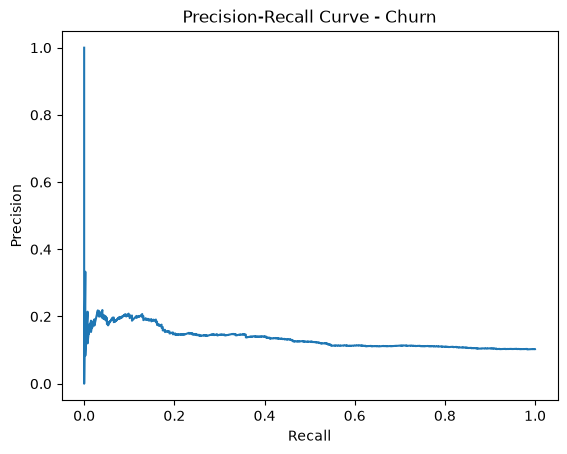

In [108]:
# Calculate precision and recall for multiple thresholds
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(
    y_test_churn,
    xgb_churn_prob
)

# Plot Precision-Recall curve
plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Churn")
plt.show()

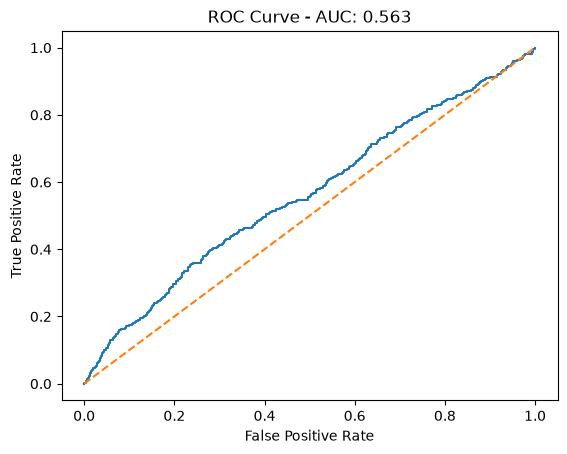

In [109]:
# Import ROC functions
from sklearn.metrics import roc_curve, roc_auc_score

# Calculate ROC points
fpr, tpr, roc_thresholds = roc_curve(
    y_test_churn,
    xgb_churn_prob
)

# Calculate ROC-AUC
auc = roc_auc_score(
    y_test_churn,
    xgb_churn_prob
)

# Plot ROC curve
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve - AUC: {auc:.3f}")
plt.show()

In [110]:
# Calculate F1 score for each threshold
f1_scores = (
    2 * precision[:-1] * recall[:-1]
    / (precision[:-1] + recall[:-1] + 1e-10)
)

# Find index of highest F1 score
best_index = np.argmax(f1_scores)

# Get best threshold
best_threshold = thresholds[best_index]

print("Best Threshold:", round(best_threshold, 3))
print("Precision:", round(precision[best_index], 3))
print("Recall:", round(recall[best_index], 3))
print("F1 Score:", round(f1_scores[best_index], 3))

Best Threshold: 0.438
Precision: 0.141
Recall: 0.399
F1 Score: 0.209


In [111]:
# Convert churn probability into final prediction
final_churn_pred = (
    xgb_churn_prob >= best_threshold
).astype(int)

In [112]:
# Evaluate final threshold-based predictions
print(
    classification_report(
        y_test_churn,
        final_churn_pred,
        target_names=["Renewed", "Churn"]
    )
)

              precision    recall  f1-score   support

     Renewed       0.91      0.72      0.81      3445
       Churn       0.14      0.40      0.21       396

    accuracy                           0.69      3841
   macro avg       0.53      0.56      0.51      3841
weighted avg       0.83      0.69      0.74      3841



In [114]:
# Final confusion matrix
final_cm = confusion_matrix(
    y_test_churn,
    final_churn_pred
)

print(final_cm)

[[2484  961]
 [ 238  158]]


In [115]:
# Library for saving Python ML objects
import joblib

In [116]:
# Path where trained models will be stored
MODEL_DIR = PROJECT_ROOT / "models"

# Create folder if it does not exist
MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [117]:
# Save complete preprocessing + XGBoost pipeline
joblib.dump(
    xgb_model,
    MODEL_DIR / "renewal_xgboost_model.joblib"
)

print("Model saved successfully")

Model saved successfully


In [118]:
# Save selected churn threshold
joblib.dump(
    best_threshold,
    MODEL_DIR / "renewal_churn_threshold.joblib"
)

['c:\\Users\\asus\\Documents\\insurance-ai-copilot\\models\\renewal_churn_threshold.joblib']

In [119]:
# Import library used to save/load ML models
import joblib

# Load saved XGBoost pipeline
loaded_model = joblib.load(
    MODEL_DIR / "renewal_xgboost_model.joblib"
)

# Load saved churn threshold
loaded_threshold = joblib.load(
    MODEL_DIR / "renewal_churn_threshold.joblib"
)

print("Model and threshold loaded successfully")

Model and threshold loaded successfully


In [120]:
# Select one unseen record from test data
sample_customer = X_test.iloc[[0]]

sample_customer

,AGE,ANNUAL_INCOME,CREDIT_SCORE,SUM_INSURED,ANNUAL_PREMIUM,RISK_SCORE,PREMIUM_INCREASE_PCT,CUSTOMER_TENURE_YEARS,TOTAL_PAYMENTS,AVG_PAYMENT_DELAY,...,MAX_CLAIM_AMOUNT,GENDER,MARITAL_STATUS,OCCUPATION,STATE,CUSTOMER_RISK_SEGMENT,POLICY_TYPE,SALES_CHANNEL,PAYMENT_MODE,RISK_BAND
15363,27,1779698,676,2501928,21678,322,3.837992,7.52909,1.0,15.0,...,29920.0,Female,Single,Business Owner,Odisha,Low,Whole Life,Broker,Monthly,Low


In [121]:
# Probability that customer will renew
renewal_probability = loaded_model.predict_proba(
    sample_customer
)[0, 1]

# Convert renewal probability into churn probability
churn_probability = 1 - renewal_probability

print("Renewal Probability:", round(renewal_probability, 3))
print("Churn Probability  :", round(churn_probability, 3))

Renewal Probability: 0.679
Churn Probability  : 0.321


In [122]:
# Final business prediction using selected churn threshold
churn_prediction = int(
    churn_probability >= loaded_threshold
)

print("Threshold:", round(float(loaded_threshold), 3))

if churn_prediction == 1:
    print("Prediction: High Risk of Non-Renewal")
else:
    print("Prediction: Likely to Renew")

Threshold: 0.438
Prediction: Likely to Renew


In [123]:
# Actual outcome of the same test record
actual = y_test_churn.iloc[0]

print("Actual Churn:", actual)
print("Predicted Churn:", churn_prediction)

Actual Churn: 0
Predicted Churn: 0


In [124]:
# Folder for processed/model-ready datasets
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

# Create folder if it does not exist
PROCESSED_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# Save final renewal modeling dataset
model_df.to_csv(
    PROCESSED_DIR / "renewal_model_data.csv",
    index=False
)

print("Renewal modeling dataset saved successfully")

Renewal modeling dataset saved successfully
